In [1]:
import pandas as pd
df=pd.read_csv("../data/processed/labeled_prs.csv")

In [4]:
#sorting by time 
df["merged_at"]=pd.to_datetime(df["merged_at"])
df=df.sort_values("merged_at"). reset_index(drop=True)

In [ ]:
#for each author, look only at their PAST prs
grouped = df.groupby("author")

In [6]:
# how many PRs did this author merge before this one?
df["author_past_prs"] = grouped.cumcount()

In [7]:
# how many of those past PRs were buggy?
# shift(1) is the anti-leakage trick: it excludes the current PR's own label
past_bugs = grouped["label"].transform(lambda s: s.shift(1).cumsum())
df["author_past_bugs"] = past_bugs.fillna(0)

In [8]:
# bug rate = past bugs / past PRs (0 for first-timers)
df["author_past_bug_rate"] = (
    df["author_past_bugs"] / df["author_past_prs"]
).fillna(0)

In [9]:
df["is_first_pr"] = (df["author_past_prs"] == 0).astype(int)

In [11]:
# save the enriched dataset
df.to_csv("../data/processed/labeled_prs_v2.csv", index=False)
df[["number", "author", "author_past_prs", "author_past_bug_rate", "is_first_pr", "label"]].head(5)

,number,author,author_past_prs,author_past_bug_rate,is_first_pr,label
0,4394,zaneb,0,0.0,1,0
1,4442,DemetriosBairaktaris,0,0.0,1,1
2,4451,jdufresne,0,0.0,1,1
3,4460,jdufresne,1,1.0,0,0
4,4459,jdufresne,2,0.5,0,0


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

features = ["additions", "deletions", "changed_files", "commits",
            "comments", "review_comments", "num_files",
            "author_past_prs", "author_past_bug_rate", "is_first_pr"]

In [13]:
#train test split
X = df[features]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



In [15]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
print("-- Logistic Regression (10 features) --")
print(classification_report(y_test, lr.predict(X_test)))
print("AUC:", round(roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1]), 3))

-- Logistic Regression (10 features) --
              precision    recall  f1-score   support

           0       0.66      0.97      0.78        60
           1       0.83      0.25      0.38        40

    accuracy                           0.68       100
   macro avg       0.75      0.61      0.58       100
weighted avg       0.73      0.68      0.62       100

AUC: 0.695


In [16]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
print("-- Random Forest (10 features) --")
print(classification_report(y_test, rf.predict(X_test)))
print("AUC:", round(roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]), 3))

-- Random Forest (10 features) --
              precision    recall  f1-score   support

           0       0.64      0.73      0.68        60
           1       0.48      0.38      0.42        40

    accuracy                           0.59       100
   macro avg       0.56      0.55      0.55       100
weighted avg       0.58      0.59      0.58       100

AUC: 0.609


<Axes: title={'center': 'Feature Importance — with author history'}>

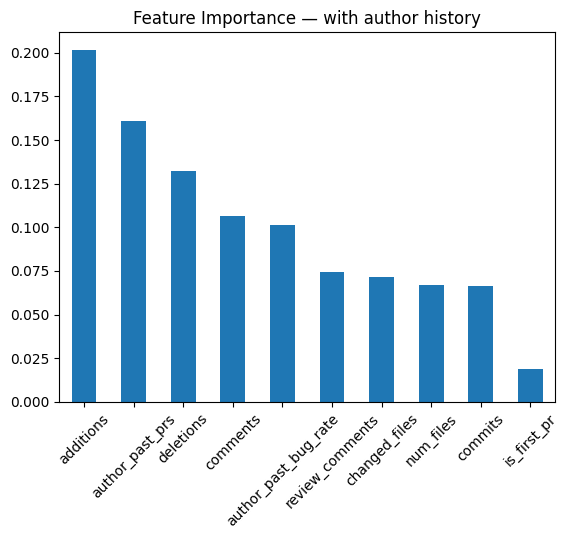

In [17]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
importances.plot(kind="bar", rot=45, title="Feature Importance — with author history")

In [18]:
print(df["is_first_pr"].mean())        # what fraction are first-timers?
print(df["author"].value_counts().head(10))  # who are the repeat authors?

0.45
author
nateprewitt        134
dependabot[bot]     53
jdufresne           16
sigmavirus24        13
graingert            7
hugovk               6
Stevoisiak           6
sethmlarson          6
sayzlim              5
kkirsche             4
Name: count, dtype: int64
